# Active-Learning Iteration 0 — Coverage Analysis (Universal/Foundation Model)

**Context**

| Group | N | Meaning |
|---|---|---|
| **T** | 6 | Used to **finetune** MACE → maceTrial0 |
| **V** | 2 | Held-out **validation** during finetuning |
| **Te** | 2 | **Test** set (unseen during training) |
| **FPS_other** | 10 | Other fps_seed candidates (next AL iteration) |
| **OOD** | 1 | Out-of-distribution test case (Case3) |
| **pool** | ~5277 | Everything else |

> **Question**: In the *universal/foundation* model's latent space, how well does T cover V, Te, FPS_other, and the pool?  How does it compare to the finetuned model?  Where does the OOD Case3 structure lie?

## 1. Imports & Config

In [1]:
import json
import os

import matplotlib.patheffects as pe
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from scipy.spatial.distance import cdist
from sklearn.decomposition import PCA

np.random.seed(42)

# ── Paths ─────────────────────────────────────────────────────────────────────
# Universal/foundation model structure-level latents (list of dicts with 'file' and 'structure_embedding')
JSON_UNIV    = "/home/mehuldarak/athena/structure_level_latents/structure_level_latents_all.json"
FPS_SEED_DIR = "/home/mehuldarak/athena/structure_level_latents/fps_seed"
OUTPUT_DIR   = "/home/mehuldarak/athena/structure_level_latents/fps_coverage_universal"

# OOD Test Case — per-atom latents, need mean-pooling
OOD_EXTXYZ_UNIV = "/home/mehuldarak/athena/Case3VASP/Case3_univOMAT.extxyz"
OOD_NAME        = "Case3_univOMAT"

os.makedirs(OUTPUT_DIR, exist_ok=True)

# ── PCA config ─────────────────────────────────────────────────────────────────
USE_PCA      = True
PCA_VAR      = 0.95   # keep 95 % explained variance
PCA_MIN_DIMS = 32

print("Config ready. Output →", OUTPUT_DIR)

Config ready. Output → /home/mehuldarak/athena/structure_level_latents/fps_coverage_universal


## 2. Label Definitions

Filenames are matched by **basename** only (path-agnostic).

In [2]:
T_NAMES = {
    "Li_110_slab__LLZO_001_Zr_code93_sto_bestgap_2.50A_r_T550K_3675.cif",
    "Li_100_slab__LLZO_011_La_code71_sto_bestgap_3.00A_r_T550K_25.cif",
    "Li_100_slab__LLZO_110_Li_order17_off_bestgap_2.50A_r_T1100K_75.cif",
    "Li_100_slab__LLZO_010_La_order0_off_bestgap_2.50A_r_T1100K_2200.cif",
    "Li_100_slab__LLZO_010_La_order0_off_bestgap_2.50A_r_T1100K_3800.cif",
    "Li_100_slab__LLZO_001_Zr_code93_sto_bestgap_3.00A_r_T550K_125.cif",
}

V_NAMES = {
    "Li_100_slab__LLZO_001_Zr_code93_sto_bestgap_3.00A_r_T1100K_12100.cif",
    "Li_100_slab__LLZO_010_La_order0_off_bestgap_2.50A_r_T1100K_350.cif",
}

# Te were provided without .cif extension – match both forms
Te_PREFIXES = {
    "Li_110_slab__LLZO_001_Zr_code93_sto_bestgap_2.50A_r_T1100K_200",
    "Li_110_slab__LLZO_010_La_order0_off_bestgap_2.00A_r_T1100K_4775",
}

# All 20 fps_seed stems (reads from the fps_seed directory)
FPS_SEED_NAMES = set(os.listdir(FPS_SEED_DIR))
print(f"fps_seed has {len(FPS_SEED_NAMES)} files")

def get_label(full_key: str) -> str:
    stem = os.path.basename(full_key)
    if stem in T_NAMES:
        return "T"
    if stem in V_NAMES:
        return "V"
    for prefix in Te_PREFIXES:
        if stem == prefix or stem == prefix + ".cif":
            return "Te"
    if stem in FPS_SEED_NAMES:
        return "FPS_other"
    return "pool"

fps_seed has 20 files


## 3. Load Universal Model Latents

The universal model JSON is a **list** of dicts with keys `file` and `structure_embedding`  
(unlike the finetuned model JSONs which are plain `{filename: embedding}` dicts).

In [3]:
print("Loading universal JSON …")
with open(JSON_UNIV) as f:
    raw = json.load(f)

# raw is a list of {"file": ..., "structure_embedding": [...], ...}
filenames  = [entry["file"] for entry in raw]
embeddings = np.array([entry["structure_embedding"] for entry in raw], dtype=np.float32)
labels_arr = np.array([get_label(k) for k in filenames])

print(f"  Total structures: {len(filenames)}")
print(f"  Embedding dim: {embeddings.shape[1]}")

cnt = pd.Series(labels_arr).value_counts()
print("\nLabel counts:")
print(cnt.to_string())

# Sanity: all 20 fps_seed names should be labelled
all_basenames = {os.path.basename(k) for k in filenames}
unlabelled_seeds = [n for n in FPS_SEED_NAMES if n not in all_basenames]
if unlabelled_seeds:
    print("\n⚠ fps_seed files NOT found in latent JSON:", unlabelled_seeds)
else:
    print("\n✓ All fps_seed structures found in latent JSON")

Loading universal JSON …
  Total structures: 5297
  Embedding dim: 256

Label counts:
pool         5277
FPS_other      10
T               6
V               2
Te              2

✓ All fps_seed structures found in latent JSON


## 4. OOD Test Case — Mean-Pool Per-Atom Latents

Case3 is a single structure stored in an .extxyz file.  
The file contains per-atom latents (256 dims per atom).  
We **mean-pool** across all atoms to get a single structure-level embedding.

In [4]:
def load_extxyz_mean_pool(path, latent_start_col=5):
    """Read a single-frame extxyz with per-atom latents and return mean-pooled embedding."""
    with open(path) as f:
        lines = f.readlines()
    n_atoms = int(lines[0].strip())
    atom_latents = []
    for line in lines[2:2 + n_atoms]:
        parts = line.strip().split()
        lat = [float(x) for x in parts[latent_start_col:]]
        atom_latents.append(lat)
    atom_latents = np.array(atom_latents, dtype=np.float32)
    return atom_latents.mean(axis=0)   # (256,)

ood_emb = load_extxyz_mean_pool(OOD_EXTXYZ_UNIV)
print(f"OOD embedding shape: {ood_emb.shape}")
print(f"OOD embedding[:5]: {ood_emb[:5]}")

# Append OOD to the main arrays
filenames  = filenames + [OOD_NAME]
embeddings = np.vstack([embeddings, ood_emb[np.newaxis, :]])
labels_arr = np.append(labels_arr, "OOD")

print(f"\nTotal after adding OOD: {len(filenames)} structures")

OOD embedding shape: (256,)
OOD embedding[:5]: [-0.07659375 -0.06894922 -0.07327578 -0.01717217 -0.06896471]

Total after adding OOD: 5298 structures


## 5. L2 Normalise + PCA

PCA is run in the high-dim space for FPS/coverage distances.  
A separate 2-D PCA is used purely for visualisation.

In [5]:
norms = np.linalg.norm(embeddings, axis=1, keepdims=True)
norms[norms == 0] = 1
emb_norm = (embeddings / norms).astype(np.float32)
print(f"L2-normalised shape: {emb_norm.shape}")

if USE_PCA:
    pca_full = PCA().fit(emb_norm)
    cumvar = np.cumsum(pca_full.explained_variance_ratio_)
    n_comp = max(PCA_MIN_DIMS, int(np.searchsorted(cumvar, PCA_VAR)) + 1)
    print(f"PCA → {n_comp} components capture {PCA_VAR*100:.0f}% variance")
    pca_hd = PCA(n_components=n_comp)
    emb_hd = pca_hd.fit_transform(emb_norm).astype(np.float32)
else:
    emb_hd = emb_norm
    print("PCA skipped – using raw normalised embeddings")

# 2-D for plotting only
pca_2d = PCA(n_components=2)
emb_2d = pca_2d.fit_transform(emb_norm)
var_2d = pca_2d.explained_variance_ratio_ * 100
print(f"2-D PCA: PC1 = {var_2d[0]:.1f}%,  PC2 = {var_2d[1]:.1f}%")

L2-normalised shape: (5298, 256)
PCA → 32 components capture 95% variance
2-D PCA: PC1 = 96.3%,  PC2 = 2.6%


## 6. Group Indices

In [6]:
idx = {lbl: np.where(labels_arr == lbl)[0]
       for lbl in ("T", "Te", "V", "FPS_other", "OOD", "pool")}

print("Group sizes:")
for g, arr in idx.items():
    print(f"  {g:<12} {len(arr)}")

emb_T = emb_hd[idx["T"]]   # used as the reference set

Group sizes:
  T            6
  Te           2
  V            2
  FPS_other    10
  OOD          1
  pool         5277


## 7. Coverage Analysis

For every structure in V, Te, FPS_other, OOD and pool:  
compute the **minimum L2 distance to the nearest T point** in the high-dim (PCA) space.  
Express as **percentile** of the pool's distance distribution → tells how well T covers it.

In [7]:
def nearest_T_dists(group_idx):
    if len(group_idx) == 0 or len(emb_T) == 0:
        return np.array([])
    return cdist(emb_hd[group_idx], emb_T).min(axis=1)

dist = {g: nearest_T_dists(idx[g]) for g in ("V", "Te", "FPS_other", "OOD", "pool")}

def coverage_percentile(query_dists):
    bg = dist["pool"]
    if len(bg) == 0:
        return np.zeros(len(query_dists))
    return np.array([float(np.mean(bg <= d)) * 100 for d in query_dists])

pct = {g: coverage_percentile(dist[g]) for g in ("V", "Te", "FPS_other", "OOD")}

print("V   → nearest T:", np.round(dist["V"],  4))
print("Te  → nearest T:", np.round(dist["Te"], 4))
print()
print("V   percentile:", np.round(pct["V"],  1))
print("Te  percentile:", np.round(pct["Te"], 1))
print()
print("FPS_other → nearest T:", np.round(dist["FPS_other"], 4))
print("FPS_other percentile:  ", np.round(pct["FPS_other"], 1))
print()
print("OOD → nearest T:", np.round(dist["OOD"], 4))
print("OOD percentile: ", np.round(pct["OOD"], 1))

V   → nearest T: [0.0206 0.0208]
Te  → nearest T: [0.0204 0.024 ]

V   percentile: [61.3 62.6]
Te  percentile: [60.6 75.2]

FPS_other → nearest T: [0.0205 0.0267 0.021  0.0233 0.0716 0.0186 0.0271 0.0182 0.0481 0.0205]
FPS_other percentile:   [ 61.   79.1  63.3  73.2 100.   51.5  79.2  48.9  79.2  60.7]

OOD → nearest T: [0.1937]
OOD percentile:  [100.]


## 8. Coverage Table

> **Low percentile** = well covered by T (gap already in training data)  
> **High percentile** = large gap → needs more training data in that region

In [15]:
rows = []
for g in ("V", "Te", "FPS_other", "OOD"):
    for ii, gi in enumerate(idx[g]):
        rows.append({
            "Label":               g,
            "Stem":                os.path.basename(filenames[gi]),
            "Dist_to_nearest_T":   dist[g][ii],
            "Percentile_vs_pool":  pct[g][ii],
        })

df_cov = (pd.DataFrame(rows)
            .sort_values("Percentile_vs_pool", ascending=False)
            .reset_index(drop=True))

# Style the table
df_cov.style.background_gradient(subset=["Percentile_vs_pool"], cmap="RdYlGn_r")

,Label,Stem,Dist_to_nearest_T,Percentile_vs_pool
0,FPS_other,Li_111_slab__LLZO_011_La_code71_sto_bestgap_2.50A_r_T550K_125.cif,0.071565,100.000000
1,OOD,Case3_univOMAT,0.193737,100.000000
2,FPS_other,Li_111_slab__LLZO_110_Li_order17_off_bestgap_2.00A_r_T1100K_3425.cif,0.048107,79.249574
3,FPS_other,Li_110_slab__LLZO_110_Li_order17_off_bestgap_2.00A_r_T1100K_25.cif,0.027080,79.230623
4,FPS_other,Li_100_slab__LLZO_001_Zr_code93_sto_bestgap_3.00A_r_T550K_4800.cif,0.026651,79.135873
5,Te,Li_110_slab__LLZO_010_La_order0_off_bestgap_2.00A_r_T1100K_4775.cif,0.024048,75.156339
6,FPS_other,Li_110_slab__LLZO_011_La_code71_sto_bestgap_2.50A_r_T550K_50.cif,0.023303,73.185522
7,FPS_other,Li_100_slab__LLZO_110_Li_order17_off_bestgap_2.50A_r_T550K_2600.cif,0.020977,63.274588
8,V,Li_100_slab__LLZO_010_La_order0_off_bestgap_2.50A_r_T1100K_350.cif,0.020833,62.611332
9,V,Li_100_slab__LLZO_001_Zr_code93_sto_bestgap_3.00A_r_T1100K_12100.cif,0.020578,61.303771


In [9]:
# Plain print for terminal / nbconvert compatibility
print(df_cov.to_string(index=False))

    Label                                                                 Stem  Dist_to_nearest_T  Percentile_vs_pool
FPS_other    Li_111_slab__LLZO_011_La_code71_sto_bestgap_2.50A_r_T550K_125.cif           0.071565          100.000000
      OOD                                                       Case3_univOMAT           0.193737          100.000000
FPS_other Li_111_slab__LLZO_110_Li_order17_off_bestgap_2.00A_r_T1100K_3425.cif           0.048107           79.249574
FPS_other   Li_110_slab__LLZO_110_Li_order17_off_bestgap_2.00A_r_T1100K_25.cif           0.027080           79.230623
FPS_other   Li_100_slab__LLZO_001_Zr_code93_sto_bestgap_3.00A_r_T550K_4800.cif           0.026651           79.135873
       Te  Li_110_slab__LLZO_010_La_order0_off_bestgap_2.00A_r_T1100K_4775.cif           0.024048           75.156339
FPS_other     Li_110_slab__LLZO_011_La_code71_sto_bestgap_2.50A_r_T550K_50.cif           0.023303           73.185522
FPS_other  Li_100_slab__LLZO_110_Li_order17_off_bestgap_

## 9. Style Config (shared across plots)

In [10]:
STYLE = {
    "pool":      dict(c="#C0C0C0", marker="o", s=7,   alpha=0.30, zorder=1,
                      label="Pool (~5277)"),
    "FPS_other": dict(c="#9467BD", marker="o", s=75,  alpha=0.85, zorder=3,
                      label="FPS_other — next AL candidates (10)"),
    "T":         dict(c="#1F77B4", marker="*", s=230, alpha=1.00, zorder=5,
                      label="T — finetuning set (6)"),
    "Te":        dict(c="#FF7F0E", marker="^", s=140, alpha=1.00, zorder=5,
                      label="Te — test (2)"),
    "V":         dict(c="#2CA02C", marker="D", s=140, alpha=1.00, zorder=5,
                      label="V — validation (2)"),
    "OOD":       dict(c="#D62728", marker="X", s=200, alpha=1.00, zorder=6,
                      label="OOD — Case3 test case (1)"),
}

def annotate(ax, gi, lbl, extra=""):
    stem = os.path.basename(filenames[gi])[-30:]
    txt = ax.annotate(
        f"{lbl}: …{stem}{extra}",
        xy=(emb_2d[gi, 0], emb_2d[gi, 1]),
        xytext=(6, 6), textcoords="offset points",
        fontsize=6.5, color=STYLE[lbl]["c"],
        arrowprops=dict(arrowstyle="->", color=STYLE[lbl]["c"], lw=0.7),
    )
    txt.set_path_effects([pe.Stroke(linewidth=2, foreground="white"), pe.Normal()])

print("Style config ready.")

Style config ready.


## 10. Plot 1 — Overview: PCA scatter + Distance histogram

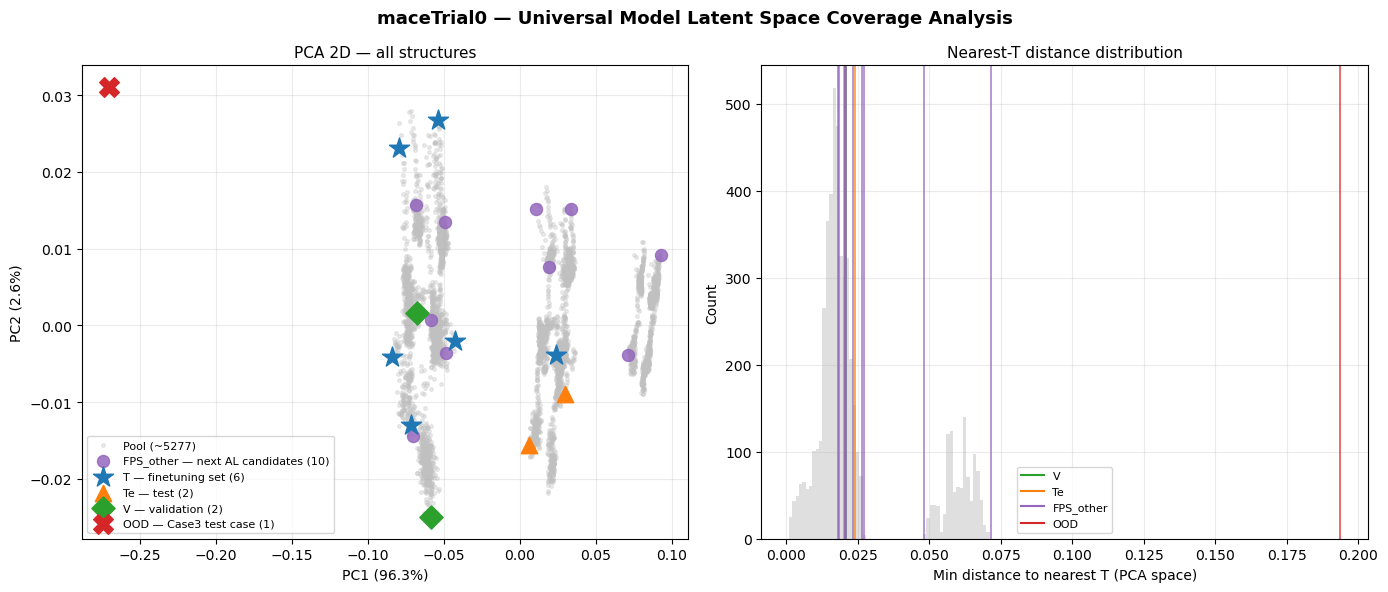

Plot 1 saved.


In [11]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6))
fig.suptitle("maceTrial0 — Universal Model Latent Space Coverage Analysis",
             fontsize=13, fontweight="bold")

# ── Left: PCA scatter ────────────────────────────────────────────────────────
ax1.set_title("PCA 2D — all structures", fontsize=11)
for lbl in ("pool", "FPS_other", "T", "Te", "V", "OOD"):
    if len(idx[lbl]):
        ax1.scatter(emb_2d[idx[lbl], 0], emb_2d[idx[lbl], 1], **STYLE[lbl])

ax1.set_xlabel(f"PC1 ({var_2d[0]:.1f}%)", fontsize=10)
ax1.set_ylabel(f"PC2 ({var_2d[1]:.1f}%)", fontsize=10)
ax1.legend(fontsize=8, loc="best")
ax1.grid(True, alpha=0.25)

# ── Right: histogram of pool distances + overlay labelled groups ─────────────
ax2.set_title("Nearest-T distance distribution", fontsize=11)
ax2.hist(dist["pool"], bins=60, color="#C0C0C0", alpha=0.5, label="pool")

colors_named = {"V": "#2CA02C", "Te": "#FF7F0E",
                "FPS_other": "#9467BD", "OOD": "#D62728"}
for g, col in colors_named.items():
    for d_val in dist[g]:
        ax2.axvline(d_val, color=col, lw=1.2, alpha=0.8)

# Legend proxies
import matplotlib.lines as mlines
handles = [mlines.Line2D([], [], color=col, lw=1.5, label=g)
           for g, col in colors_named.items()]
ax2.legend(handles=handles, fontsize=8)
ax2.set_xlabel("Min distance to nearest T (PCA space)", fontsize=10)
ax2.set_ylabel("Count", fontsize=10)
ax2.grid(True, alpha=0.25)

plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, "universal_coverage_overview.png"),
            dpi=150, bbox_inches="tight")
plt.show()
print("Plot 1 saved.")

## 11. Plot 2 — T Coverage Circles + Labelled Points

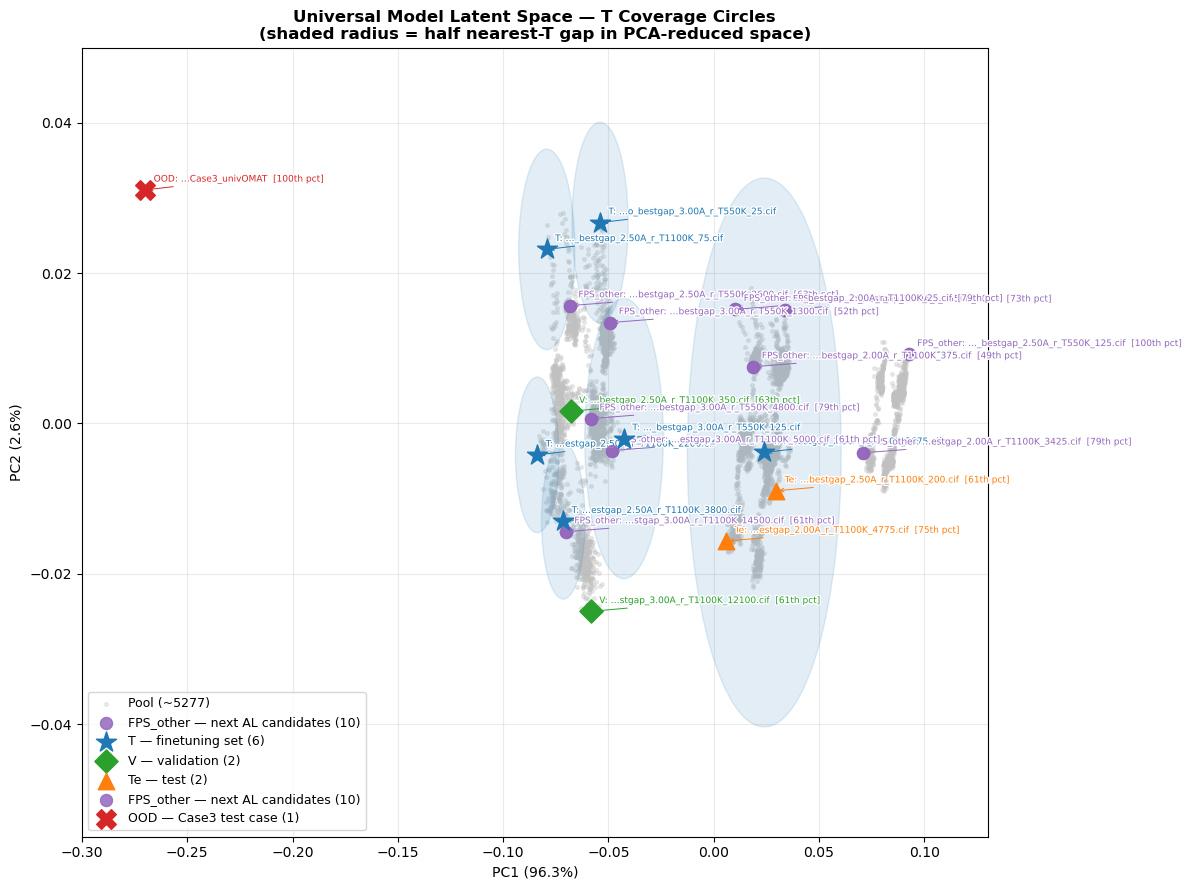

Plot 2 saved.


In [13]:
# ── Shared axis limits for cross-notebook comparison ─────────────────────────
XLIM = (-0.30, 0.13)
YLIM = (-0.055, 0.050)

fig2, ax3 = plt.subplots(figsize=(12, 9))
ax3.set_title("Universal Model Latent Space — T Coverage Circles\n"
              "(shaded radius = half nearest-T gap in PCA-reduced space)",
              fontsize=12, fontweight="bold")

ax3.scatter(emb_2d[idx["pool"], 0],      emb_2d[idx["pool"], 1],      **STYLE["pool"])
ax3.scatter(emb_2d[idx["FPS_other"], 0], emb_2d[idx["FPS_other"], 1], **STYLE["FPS_other"])

if len(idx["T"]) >= 2:
    D_TT = cdist(emb_hd[idx["T"]], emb_hd[idx["T"]])
    np.fill_diagonal(D_TT, np.inf)
    r_T = D_TT.min(axis=1) / 2.0
else:
    r_T = np.full(len(idx["T"]), 0.05)

for ii, gi in enumerate(idx["T"]):
    ax3.add_patch(plt.Circle(
        (emb_2d[gi, 0], emb_2d[gi, 1]), radius=r_T[ii],
        color=STYLE["T"]["c"], alpha=0.13, zorder=2
    ))

for lbl in ("T", "V", "Te", "FPS_other", "OOD"):
    if len(idx[lbl]):
        ax3.scatter(emb_2d[idx[lbl], 0], emb_2d[idx[lbl], 1], **STYLE[lbl])
        for k, gi in enumerate(idx[lbl]):
            extra = ""
            if lbl in ("V", "Te", "FPS_other", "OOD"):
                row = df_cov[df_cov["Stem"] == os.path.basename(filenames[gi])]
                if len(row):
                    extra = f"  [{row.iloc[0]['Percentile_vs_pool']:.0f}th pct]"
            annotate(ax3, gi, lbl, extra)

ax3.set_xlim(XLIM)
ax3.set_ylim(YLIM)
ax3.set_xlabel(f"PC1 ({var_2d[0]:.1f}%)", fontsize=10)
ax3.set_ylabel(f"PC2 ({var_2d[1]:.1f}%)", fontsize=10)
ax3.legend(fontsize=9, loc="best")
ax3.grid(True, alpha=0.25)

plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, "universal_coverage_T_radii.png"),
            dpi=150, bbox_inches="tight")
plt.show()
print("Plot 2 saved.")
